In [121]:
# Import the libraries 
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score, r2_score, mean_squared_error
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [123]:
# Import the data
hotel=pd.DataFrame()

In [125]:
hotel=pd.read_excel("hotel_transactions.xlsx")

In [126]:
hotel.head()

,hotel_name,reg,state,types,cus_name,phone_no,emel,customer_rating,membership,rep_guest,...,sales,dep,d_s,arrival_date,depature_date,ADR,Sales Person,pos,comm_pay,customer_review
0,"Lexis Suites, Penang",North,Penang,City Hotel,Ernest Barnes,669-792-1661,Ernest.Barnes31@outlook.com,5,Platinum,0,...,4280.0,300,Refunded,2024-04-02,2024-04-10,0.0,Leo,Sales Manager,15,Excellent
1,"Lexis Suites, Penang",North,Penang,City Hotel,Andrea Baker,858-637-6955,Andrea_Baker94@aol.com,4,Gold,0,...,3945.0,300,Refunded,2024-07-13,2024-07-19,0.0,Amy,Sales Executive,20,Very Good
2,"Lexis Suites, Penang",North,Penang,City Hotel,Rebecca Parker,652-885-2745,Rebecca_Parker@comcast.net,5,Platinum,0,...,6695.0,300,Refunded,2024-08-22,2024-09-04,75.0,Amy,Sales Executive,15,Excellent
3,"Le Méridien, Sabah",East,Sabah,Resort Hotel,Laura Murray,364-656-8427,Laura_M@gmail.com,4,Platinum,0,...,10200.0,300,Refunded,2024-05-16,2024-05-22,75.0,Leo,Sales Manager,30,Very Good
4,"The Hilton, Kuala Lumpur",Central,Kuala Lumpur,City Hotel,Linda Hines,713-226-5883,LHines@verizon.com,5,Platinum,0,...,3325.0,300,Forfeited,2024-02-05,2024-02-10,98.0,Leo,Sales Manager,20,Excellent


#### Drop irrelevant columns as they do not have important information, for practical uses, the data will be use as one hotel (hotel name, state, types, customer rating (same as customer review), repeat guests, previous cancellation, card number, reservation status, assignation room, deposit and ADR)

In [130]:
hotel = hotel.drop(columns=['hotel_name', 'state', 'types', 'customer_rating', 'rep_guest', 'prev_cancel', 'card_no', 'resv_status', 'assgn_room', 'dep', 'ADR'])

hotel.head()

,reg,cus_name,phone_no,emel,membership,payment_method,meal,cus_seg,room-type,adult,...,disc,disc_amt,sales,d_s,arrival_date,depature_date,Sales Person,pos,comm_pay,customer_review
0,North,Ernest Barnes,669-792-1661,Ernest.Barnes31@outlook.com,Platinum,Credit Card,BB,Individual,Single Room,2,...,0.10,440.0,4280.0,Refunded,2024-04-02,2024-04-10,Leo,Sales Manager,15,Excellent
1,North,Andrea Baker,858-637-6955,Andrea_Baker94@aol.com,Gold,Credit Card,BB,Individual,Deluxe Room,2,...,0.05,195.0,3945.0,Refunded,2024-07-13,2024-07-19,Amy,Sales Executive,20,Very Good
2,North,Rebecca Parker,652-885-2745,Rebecca_Parker@comcast.net,Platinum,Online Transfer,BB,Corporate,Single Room,1,...,0.10,715.0,6695.0,Refunded,2024-08-22,2024-09-04,Amy,Sales Executive,15,Excellent
3,East,Laura Murray,364-656-8427,Laura_M@gmail.com,Platinum,Credit Card,BB,Family,Royal Suite,3,...,0.10,1080.0,10200.0,Refunded,2024-05-16,2024-05-22,Leo,Sales Manager,30,Very Good
4,Central,Linda Hines,713-226-5883,LHines@verizon.com,Platinum,Online Transfer,BB,Family,Deluxe Room,2,...,0.10,325.0,3325.0,Forfeited,2024-02-05,2024-02-10,Leo,Sales Manager,20,Excellent


In [132]:
#Checking the data types of columns
hotel.dtypes

reg                        object
cus_name                   object
phone_no                   object
emel                       object
membership                 object
payment_method             object
meal                       object
cus_seg                    object
room-type                  object
adult                       int64
(child)                     int64
dis_channel                object
price                       int64
nights                      int64
package_                    int64
gross                       int64
disc                      float64
disc_amt                  float64
sales                     float64
d_s                        object
arrival_date       datetime64[ns]
depature_date      datetime64[ns]
Sales Person               object
pos                        object
comm_pay                    int64
customer_review            object
dtype: object

## Pre processing data

In [135]:
hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6050 entries, 0 to 6049
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   reg              6050 non-null   object        
 1   cus_name         6050 non-null   object        
 2   phone_no         6050 non-null   object        
 3   emel             6050 non-null   object        
 4   membership       5967 non-null   object        
 5   payment_method   6050 non-null   object        
 6   meal             6050 non-null   object        
 7   cus_seg          6050 non-null   object        
 8   room-type        6050 non-null   object        
 9   adult            6050 non-null   int64         
 10  (child)          6050 non-null   int64         
 11  dis_channel      6050 non-null   object        
 12  price            6050 non-null   int64         
 13  nights           6050 non-null   int64         
 14  package_         6050 non-null   int64  

## Missing values

In [138]:
hotel.isnull().sum()

reg                 0
cus_name            0
phone_no            0
emel                0
membership         83
payment_method      0
meal                0
cus_seg             0
room-type           0
adult               0
(child)             0
dis_channel         0
price               0
nights              0
package_            0
gross               0
disc                0
disc_amt            0
sales               0
d_s                 0
arrival_date        0
depature_date       0
Sales Person        0
pos                 0
comm_pay            0
customer_review     0
dtype: int64

In [140]:
hotel["membership"].value_counts()

membership
Platinum    3018
Gold        2949
Name: count, dtype: int64

### Replace the value N/A in the column membership with 'do not have any'

In [143]:
hotel['membership'] = hotel['membership'].fillna("Do not have any")

In [145]:
hotel["membership"].value_counts()

membership
Platinum           3018
Gold               2949
Do not have any      83
Name: count, dtype: int64

### Fill the value '-' in the column (child) to the number '0' 

In [148]:
hotel['(child)'] = hotel['(child)'].replace("-", 0)

In [150]:
hotel["(child)"].value_counts()

(child)
0    4530
2     766
1     745
3       6
4       3
Name: count, dtype: int64

### Change the values in the column 'customer_review' to better understanding 

In [153]:
hotel['customer_review'] = hotel['customer_review'].replace("Good", "Fair")
hotel['customer_review'] = hotel['customer_review'].replace("Very Good", "Good")

In [155]:
hotel["customer_review"].value_counts()

customer_review
Excellent    1958
Good         1512
Fair         1333
Poor         1247
Name: count, dtype: int64

## Membership and customer segmentation

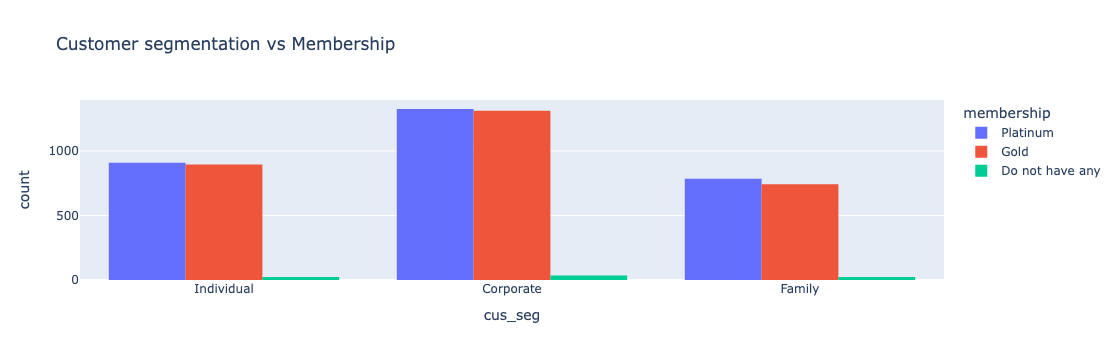

In [158]:
fig_membership_seg = px.histogram(hotel, x='cus_seg', color='membership',
                                 barmode='group',
                                title='Customer segmentation vs Membership')
fig_membership_seg.show()

## Room type and customer segmentation

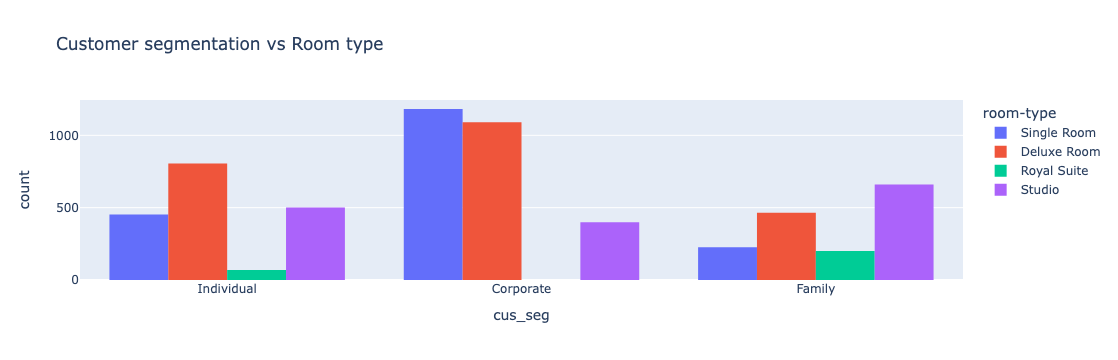

In [161]:
fig_room_seg = px.histogram(hotel, x='cus_seg', color='room-type',
                                 barmode='group',
                                title='Customer segmentation vs Room type')
fig_room_seg.show()

## Payment method and customer segmentation

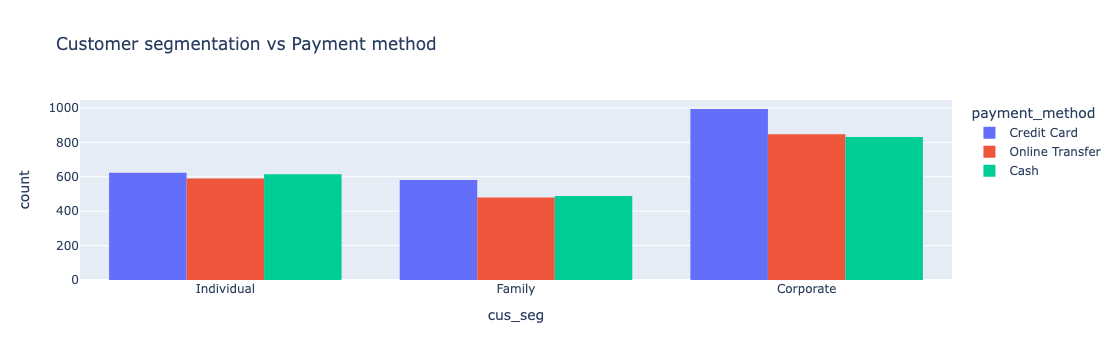

In [164]:
fig_payment = px.histogram(hotel, x='cus_seg', color='payment_method',
                                 barmode='group',
                                title='Customer segmentation vs Payment method')
fig_payment.show()

## Meal type and customer segmentation

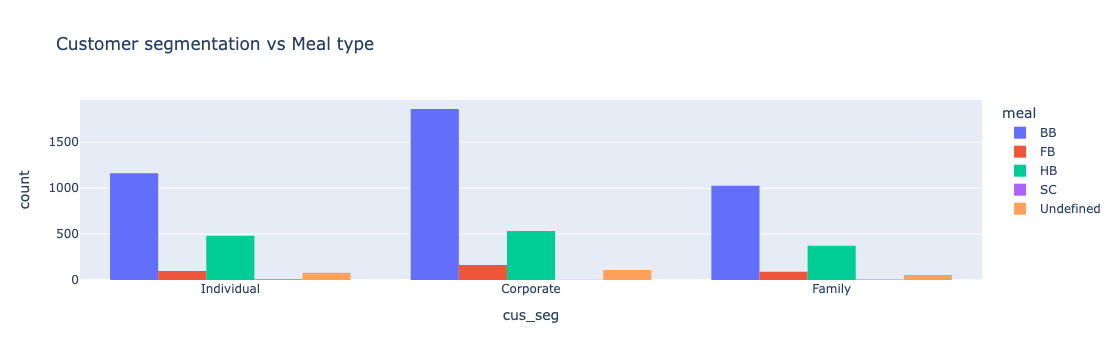

In [167]:
fig_meal = px.histogram(hotel, x='cus_seg', color='meal',
                                 barmode='group',
                                title='Customer segmentation vs Meal type')
fig_meal.show()

## Distribution channel and customer segmentation

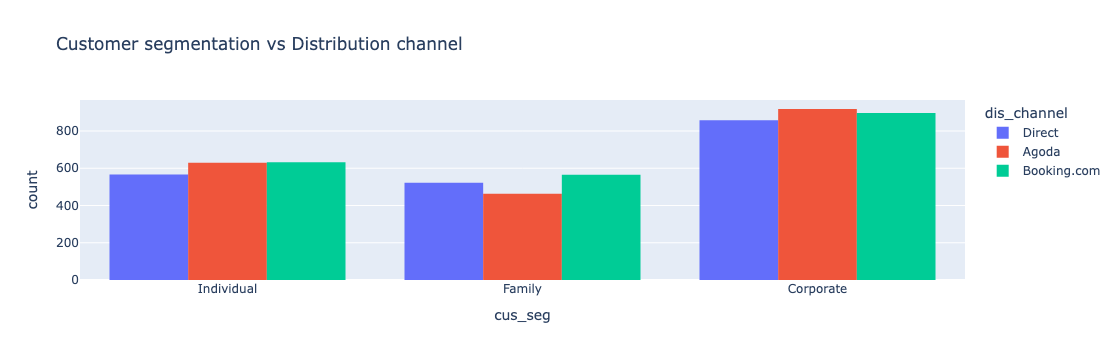

In [170]:
fig_dis_chan = px.histogram(hotel, x='cus_seg', color='dis_channel',
                                 barmode='group',
                                title='Customer segmentation vs Distribution channel')
fig_dis_chan.show()

## Discount applied through distribution channel for every customer segmentation

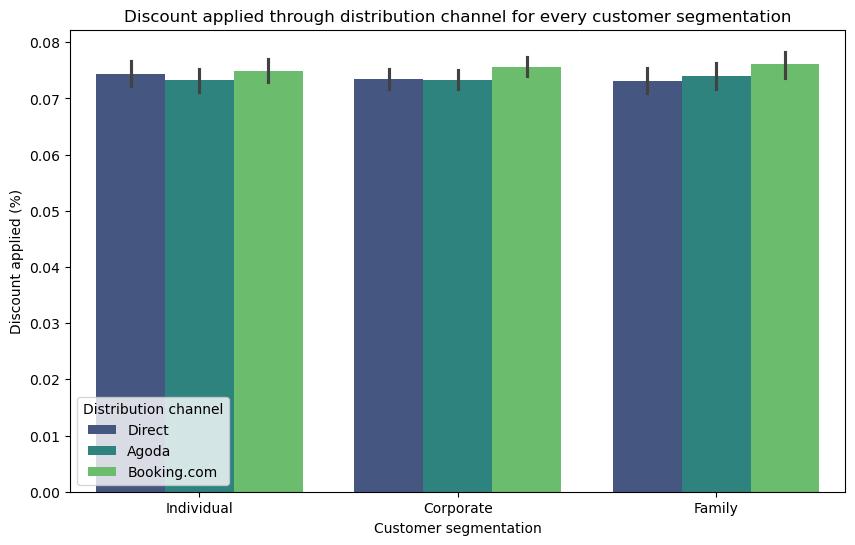

In [173]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x='cus_seg', y='disc', hue='dis_channel', data=hotel, palette='viridis')

plt.title("Discount applied through distribution channel for every customer segmentation")
plt.xlabel("Customer segmentation")
plt.ylabel("Discount applied (%)")
plt.legend(title="Distribution channel")
plt.show()

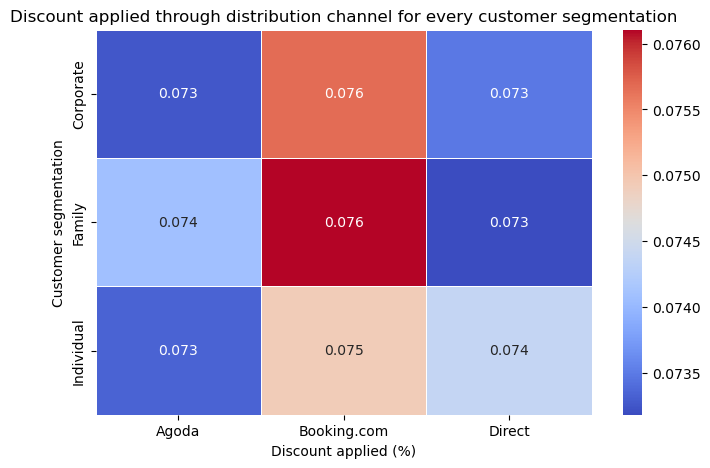

In [175]:
pivot_table = hotel.pivot_table(index='cus_seg', columns='dis_channel', values='disc', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Discount applied through distribution channel for every customer segmentation")
plt.xlabel("Discount applied (%)")
plt.ylabel("Customer segmentation")
plt.show()


## Membership and customer review

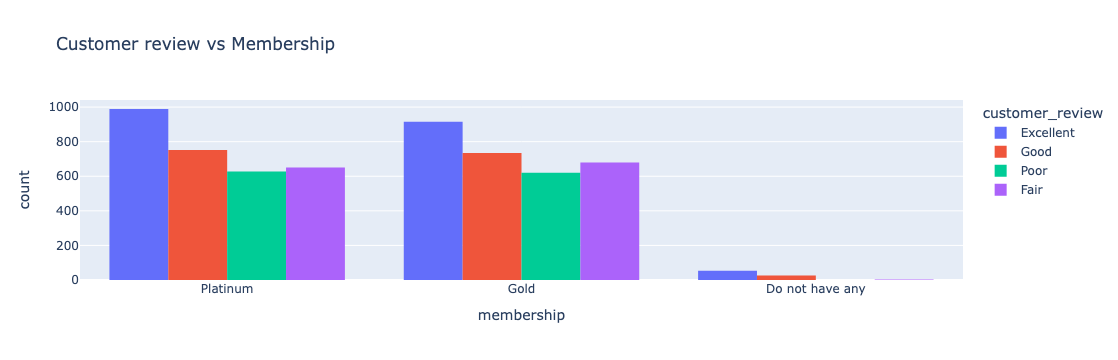

In [178]:
fig_membership_review = px.histogram(hotel, x='membership', color='customer_review',
                                 barmode='group',
                                title='Customer review vs Membership')
fig_membership_review.show()

## Customer review and customer segmentation

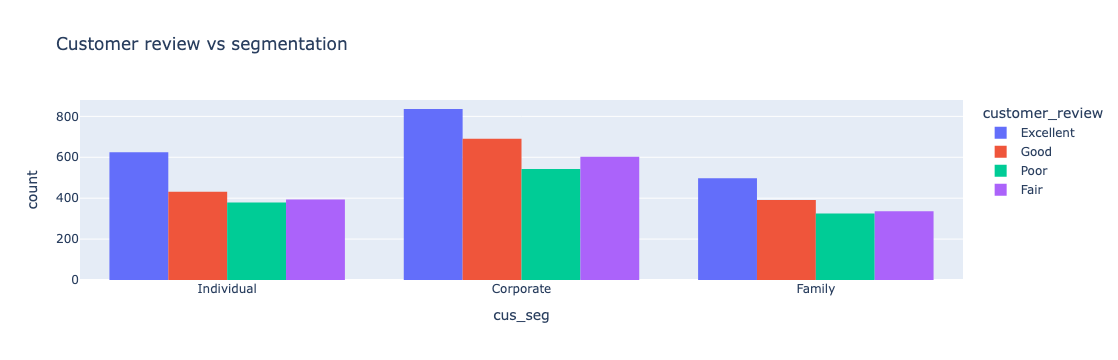

In [181]:
fig_seg_review = px.histogram(hotel, x='cus_seg', color='customer_review',
                                 barmode='group',
                                title='Customer review vs segmentation')
fig_seg_review.show()